# Week 4: Nemotron Nano 30B Experiments (FDS)
**Model:** `nemotron-3-nano:30b-a3b-q4_K_M` via Ollama (FDS - RTX 5000 Ada 32 GB)
**Depends on:** `week1_baselines.ipynb` must be run first to generate shared splits.

**This notebook:**
1. Loads the same train/test splits as Week 3 (75 occupations, 773 test rows)
2. Runs zero-shot experiment with reasoning ON
3. Runs few-shot experiment with reasoning ON
4. Runs zero-shot experiment with reasoning OFF
5. Compares reasoning ON vs OFF
6. K-Means cluster analysis
7. Full comparison across all models and weeks

**Baselines (Week 1):**
- Random Forest: 64.39% accuracy, Macro F1 0.6400
- XGBoost: 70.89% accuracy, Macro F1 0.7067

**Week 3 results (Nano 4B):**
- Zero-shot: 62.60% accuracy, Macro F1 0.5955
- Few-shot: 68.46% accuracy, Macro F1 0.6845

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import time
import re
import os

from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report
)
from sklearn.cluster import KMeans
from sklearn.preprocessing import LabelEncoder, StandardScaler

sns.set_theme(style="whitegrid")

RESULTS_DIR = "../results"
DATA_DIR    = "../data"
os.makedirs(RESULTS_DIR, exist_ok=True)

print("Imports OK")

Imports OK


## 2. Configuration

In [2]:
OLLAMA_URL = "http://localhost:11434/v1/chat/completions"
MODEL_NAME = "nemotron-3-nano:30b-a3b-q4_K_M"

TRAIN_PATH = "../data/week3_train_5000.csv"
TEST_PATH  = "../data/week3_test_5000.csv"

# Previous results for comparison
BASELINES = {
    "Random Forest":    {"accuracy": 0.6439, "macro_f1": 0.6400, "auc_roc": 0.6795, "ms_per_row": 0.071},
    "XGBoost":          {"accuracy": 0.7089, "macro_f1": 0.7067, "auc_roc": 0.7447, "ms_per_row": 0.006},
    "Nano 4B zero-shot":{"accuracy": 0.6260, "macro_f1": 0.5955, "auc_roc": 0.6058, "ms_per_row": 3258},
    "Nano 4B few-shot": {"accuracy": 0.6846, "macro_f1": 0.6845, "auc_roc": 0.6894, "ms_per_row": 4553},
}

# Verify Ollama is running
try:
    r = requests.get("http://localhost:11434/api/tags", timeout=5)
    models = [m["name"] for m in r.json().get("models", [])]
    print(f"Ollama running. Available models: {models}")
    if MODEL_NAME in models:
        print(f"Model ready: {MODEL_NAME}")
    else:
        print(f"Model not found: {MODEL_NAME}")
        print(f"Run: ollama pull {MODEL_NAME}")
except Exception as e:
    print(f"Ollama not reachable: {e}")
    print("Run: ollama serve")

Ollama running. Available models: ['nemotron-3-nano:4b', 'nemotron-3-nano:30b-a3b-q4_K_M']
Model ready: nemotron-3-nano:30b-a3b-q4_K_M


## 3. Load Shared Splits

In [3]:
if not os.path.exists(TRAIN_PATH) or not os.path.exists(TEST_PATH):
    print("Split files not found. Run week1_baselines.ipynb first.")
else:
    df_train = pd.read_csv(TRAIN_PATH)
    df_test  = pd.read_csv(TEST_PATH)

    print(f"Train: {len(df_train):,} rows")
    print(f"Test:  {len(df_test):,} rows")
    print(f"Unique occupations in test: {df_test['occupation'].nunique()}")
    print(f"\nTest label balance:")
    print(df_test["label_name"].value_counts())
    df_test.head(3)

Train: 2,460 rows
Test:  615 rows
Unique occupations in test: 75

Test label balance:
label_name
not_college    336
college        279
Name: count, dtype: int64


## 4. Occupation Audit
Same audit as Week 3 - 75 occupations categorized as yes/no/maybe.

In [4]:
occupation_audit = {
    "accountant or auditor":                                                "yes",
    "assembler or fabricator":                                              "no",
    "automotive service technician or mechanic":                            "no",
    "bookkeeping accounting or auditing clerk":                             "no",
    "bus driver school":                                                    "no",
    "business operations specialist":                                       "maybe",
    "carpenter":                                                            "no",
    "cashier":                                                              "no",
    "chief executive":                                                      "yes",
    "childcare worker":                                                     "no",
    "civil engineer":                                                       "yes",
    "clergy":                                                               "yes",
    "computer occupation":                                                  "maybe",
    "computer support specialist":                                          "maybe",
    "computer systems analyst":                                             "yes",
    "construction laborer":                                                 "no",
    "construction manager":                                                 "yes",
    "cook":                                                                 "no",
    "courier or messenger":                                                 "no",
    "customer service representative":                                      "no",
    "driver sales worker or truck driver":                                  "no",
    "education or childcare administrator":                                 "yes",
    "electrician":                                                          "no",
    "elementary or middle school teacher":                                  "yes",
    "engineer":                                                             "yes",
    "engineering technologist or technician":                               "maybe",
    "financial manager":                                                    "yes",
    "first line supervisor of non retail sales worker":                     "maybe",
    "first line supervisor of office or administrative support worker":     "maybe",
    "first line supervisor of production or operating worker":              "maybe",
    "first line supervisor of retail sales worker":                         "maybe",
    "food service manager":                                                 "maybe",
    "general or operations manager":                                        "maybe",
    "human resources worker":                                               "yes",
    "industrial truck or tractor operator":                                 "no",
    "inspector tester sorter sampler or weigher":                           "no",
    "insurance sales agent":                                                "maybe",
    "janitor or building cleaner":                                          "no",
    "laborer or freight stock or material mover":                           "no",
    "landscaping or groundskeeping worker":                                 "no",
    "licensed practical or licensed vocational nurse":                      "maybe",
    "maid or housekeeping cleaner":                                         "no",
    "maintenance or repair worker general":                                 "no",
    "management analyst":                                                   "yes",
    "manager":                                                              "maybe",
    "market research analyst or marketing specialist":                      "yes",
    "mathematical science occupation":                                      "yes",
    "medical or health services manager":                                   "yes",
    "miscellaneous agricultural worker":                                    "no",
    "nursing assistant":                                                    "no",
    "office clerk general":                                                 "no",
    "painter or paperhanger":                                               "no",
    "personal care aide":                                                   "no",
    "personal financial advisor":                                           "yes",
    "physician":                                                            "yes",
    "police officer":                                                       "maybe",
    "postsecondary teacher":                                                "yes",
    "production worker":                                                    "no",
    "project management specialist":                                        "yes",
    "property real estate or community association manager":                "maybe",
    "real estate broker or sales agent":                                    "maybe",
    "receptionist or information clerk":                                    "no",
    "registered nurse":                                                     "yes",
    "retail salesperson":                                                   "no",
    "sales representative of services":                                     "maybe",
    "sales representative wholesale or manufacturing":                      "maybe",
    "secondary school teacher":                                             "yes",
    "secretary or administrative assistant":                                "no",
    "security guard or gambling surveillance officer":                      "no",
    "shipping receiving or inventory clerk":                                "no",
    "software developer":                                                   "yes",
    "stocker or order filler":                                              "no",
    "teacher or instructor":                                                "yes",
    "teaching assistant":                                                   "maybe",
    "waiter or waitress":                                                   "no",
}

# Map verdicts to both splits
audit_normalized = {k.lower(): v for k, v in occupation_audit.items()}
verdict_map = {"no": 0, "yes": 1, "maybe": 2}

for df in [df_train, df_test]:
    df["occ_clean"]     = df["occupation"].str.replace("_", " ").str.strip().str.lower()
    df["audit_verdict"] = df["occ_clean"].map(audit_normalized)
    df["verdict_num"]   = df["audit_verdict"].map(verdict_map)

print(f"Audited: {len(occupation_audit)} occupations")
print(f"Test rows tagged:  {df_test['audit_verdict'].notna().sum()}")
print(f"Train rows tagged: {df_train['audit_verdict'].notna().sum()}")
print(f"Train untagged:    {df_train['audit_verdict'].isna().sum()}")

Audited: 75 occupations
Test rows tagged:  615
Train rows tagged: 2460
Train untagged:    0


## 5. Helper Functions

In [5]:
SYSTEM_PROMPT = """You are an education level classifier. Given a person's demographic information,
predict whether they are college-educated (have an associates, bachelor's, or graduate degree) or not.
Think step by step, then respond with ONLY one of these two labels on the final line: college or not_college."""


def serialize_row(row):
    return (
        f"A {int(row['age'])}-year-old {str(row['sex']).lower().strip()}, "
        f"{str(row['marital_status']).replace('_', ' ').strip()}, "
        f"working as a {str(row['occupation']).replace('_', ' ').strip()}. "
        f"Located in {str(row['state']).strip()}."
    )


def build_zero_shot_prompt(row):
    return [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": (
            f"Classify this person's education level:\n\n"
            f"{serialize_row(row)}\n\n"
            f"Answer with college or not_college only."
        )}
    ]


def build_few_shot_prompt(row, examples):
    example_text = ""
    for ex in examples:
        example_text += f"Person: {serialize_row(ex)}\nLabel: {ex['label_name']}\n\n"
    return [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": (
            f"Here are some labeled examples:\n\n{example_text}"
            f"Now classify this person:\n\n"
            f"{serialize_row(row)}\n\n"
            f"Answer with college or not_college only."
        )}
    ]


def parse_response(content):
    think_match = re.search(r"<think>(.*?)</think>", content, re.DOTALL)
    trace = think_match.group(1).strip() if think_match else ""
    label_match = re.search(r"\b(not_college|college)\b", content, re.IGNORECASE)
    label = label_match.group(1).lower() if label_match else "UNKNOWN"
    return label, trace


def classify_row(messages, enable_thinking=True, timeout=180):
    # Reasoning OFF: append /no_think to the last user message
    if not enable_thinking:
        messages = [
            {"role": m["role"],
             "content": m["content"] + (" /no_think" if m["role"] == "user" else "")}
            for m in messages
        ]
    payload = {
        "model": MODEL_NAME,
        "messages": messages,
        "max_tokens": 2048,
        "temperature": 0.1,
        "stream": False,
        "options": {"num_ctx": 8192},
    }
    start = time.time()
    try:
        response = requests.post(OLLAMA_URL, json=payload, timeout=timeout).json()
        elapsed  = time.time() - start
        content  = response["choices"][0]["message"]["content"]
        tokens   = response.get("usage", {}).get("completion_tokens", 0)
        label, trace = parse_response(content)
    except Exception as e:
        elapsed = time.time() - start
        label, trace, tokens, content = "ERROR", str(e), 0, str(e)
    return {"label": label, "trace": trace, "raw": content,
            "time_ms": round(elapsed * 1000), "tokens": tokens}


print("All helper functions defined.")

All helper functions defined.


## 6. Few-shot Example Pool
Same audit dict as Week 3 - examples from audited occupations in train set only.

In [6]:
# Sample from audited train rows only - same random_state as Week 3
audited_train = df_train[df_train["audit_verdict"].notna()]

fs_college = audited_train[audited_train["label_name"] == "college"].sample(3, random_state=1)
fs_not     = audited_train[audited_train["label_name"] == "not_college"].sample(2, random_state=1)
few_shot_examples = pd.concat([fs_college, fs_not]).sample(frac=1, random_state=1).to_dict("records")

print(f"Audited train rows: {len(audited_train)}")
print(f"\nFew-shot examples (audited occupations only):")
for ex in few_shot_examples:
    verdict = audit_normalized.get(ex["occupation"].replace("_", " ").strip().lower(), "unaudited")
    print(f"  {serialize_row(ex)} -> {ex['label_name']} [{verdict}]")

Audited train rows: 2460

Few-shot examples (audited occupations only):
  A 22-year-old female, never married, working as a property real estate or community association manager. Located in MI. -> college [maybe]
  A 62-year-old female, divorced, working as a retail salesperson. Located in FL. -> college [no]
  A 57-year-old female, married present, working as a registered nurse. Located in GA. -> not_college [yes]
  A 28-year-old male, married present, working as a postsecondary teacher. Located in NE. -> college [yes]
  A 30-year-old female, married present, working as a nursing assistant. Located in TX. -> not_college [no]


## 7. Evaluation Helper

In [7]:
label_map = {"college": 1, "not_college": 0}

def evaluate_llm_results(results_df, run_name, device="fds-rtx5000"):
    valid = results_df[results_df["pred_label"].isin(["college", "not_college"])].copy()
    unknown_count = len(results_df) - len(valid)
    y_true = valid["true_label"].map(label_map)
    y_pred = valid["pred_label"].map(label_map)
    acc    = accuracy_score(y_true, y_pred)
    f1     = f1_score(y_true, y_pred, average="macro")
    auc    = roc_auc_score(y_true, y_pred)
    avg_ms = results_df["time_ms"].mean()
    avg_tokens = results_df["tokens"].mean()
    print(f"\n{'='*50}\n  {run_name}\n{'='*50}")
    print(f"  Rows evaluated: {len(valid)} / {len(results_df)}")
    print(f"  Unknown:        {unknown_count}")
    print(f"  Accuracy:       {acc:.4f}")
    print(f"  Macro F1:       {f1:.4f}")
    print(f"  AUC-ROC:        {auc:.4f}")
    print(f"  Avg time/row:   {avg_ms:.0f}ms")
    print(f"  Avg tokens:     {avg_tokens:.0f}")
    print()
    print(classification_report(y_true, y_pred, target_names=["not_college", "college"]))
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(4, 3))
    ConfusionMatrixDisplay(cm, display_labels=["not_college", "college"]).plot(ax=ax, colorbar=False)
    ax.set_title(run_name)
    plt.tight_layout()
    plt.savefig(f"{RESULTS_DIR}/cm_{run_name.replace(' ', '_').lower()}.png", dpi=150)
    plt.show()
    return {"model": run_name, "accuracy": round(acc, 4), "macro_f1": round(f1, 4),
            "auc_roc": round(auc, 4), "ms_per_row": round(avg_ms, 1),
            "avg_tokens": round(avg_tokens, 1), "unknown": unknown_count,
            "n_samples": len(valid), "week": 4, "device": device,
            "dataset": "nvidia/Nemotron-Personas-USA"}

all_results = []
print("evaluate_llm_results() defined.")

evaluate_llm_results() defined.


## 8. Timing Estimate

In [8]:
# Estimate based on 30B being roughly 2x slower than 4B
AVG_MS_ESTIMATE = 8000  # update after first run
n_test = len(df_test)

print(f"=== TIMING ESTIMATE ===")
print(f"  Test rows:            {n_test}")
print(f"  Est. per experiment:  ~{(n_test * AVG_MS_ESTIMATE / 1000) / 60:.0f} minutes")
print(f"  Three experiments:    ~{(n_test * AVG_MS_ESTIMATE / 1000 * 3) / 60:.0f} minutes total")
print()
print("Experiments to run:")
print("  A - Zero-shot  (reasoning ON)")
print("  B - Few-shot   (reasoning ON)")
print("  C - Zero-shot  (reasoning OFF)")

=== TIMING ESTIMATE ===
  Test rows:            615
  Est. per experiment:  ~82 minutes
  Three experiments:    ~246 minutes total

Experiments to run:
  A - Zero-shot  (reasoning ON)
  B - Few-shot   (reasoning ON)
  C - Zero-shot  (reasoning OFF)


## 9. Experiment A: Zero-shot (Reasoning ON)
> Expected time: see timing estimate above.

In [9]:
print(f"Starting zero-shot (reasoning ON) on {len(df_test)} rows...")
print(f"Model: {MODEL_NAME}\n")

zs_results = []
t_start = time.time()

for i, row in df_test.iterrows():
    messages = build_zero_shot_prompt(row.to_dict())
    result   = classify_row(messages, enable_thinking=True)
    zs_results.append({
        "row_id":        i,
        "input":         serialize_row(row.to_dict()),
        "occupation":    row["occupation"].replace("_", " ").strip(),
        "audit_verdict": row.get("audit_verdict", "unaudited"),
        "verdict_num":   row.get("verdict_num", -1),
        "true_label":    row["label_name"],
        "pred_label":    result["label"],
        "correct":       result["label"] == row["label_name"],
        "time_ms":       result["time_ms"],
        "tokens":        result["tokens"],
        "trace":         result["trace"],
        "raw":           result["raw"],
    })
    if (i + 1) % 100 == 0:
        elapsed   = time.time() - t_start
        done      = len(zs_results)
        remaining = (elapsed / done) * (len(df_test) - done)
        print(f"  Row {done:4d}/{len(df_test)} | Elapsed: {elapsed/60:.1f}min | Remaining: ~{remaining/60:.1f}min")

zs_df = pd.DataFrame(zs_results)
zs_df.to_csv(f"{RESULTS_DIR}/week4_zeroshot_raw.csv", index=False)
print(f"\nDone! Total time: {(time.time()-t_start)/60:.1f} minutes")
print(f"Saved: results/week4_zeroshot_raw.csv")

Starting zero-shot (reasoning ON) on 615 rows...
Model: nemotron-3-nano:30b-a3b-q4_K_M

  Row  100/615 | Elapsed: 7.3min | Remaining: ~37.5min
  Row  200/615 | Elapsed: 14.2min | Remaining: ~29.4min
  Row  300/615 | Elapsed: 21.0min | Remaining: ~22.0min
  Row  400/615 | Elapsed: 28.1min | Remaining: ~15.1min
  Row  500/615 | Elapsed: 35.0min | Remaining: ~8.1min
  Row  600/615 | Elapsed: 41.9min | Remaining: ~1.0min

Done! Total time: 42.9 minutes
Saved: results/week4_zeroshot_raw.csv


## 10. Zero-shot Results


  Nano 30B zero-shot
  Rows evaluated: 615 / 615
  Unknown:        0
  Accuracy:       0.7301
  Macro F1:       0.7291
  AUC-ROC:        0.7308
  Avg time/row:   4185ms
  Avg tokens:     187

              precision    recall  f1-score   support

 not_college       0.77      0.72      0.75       336
     college       0.69      0.74      0.71       279

    accuracy                           0.73       615
   macro avg       0.73      0.73      0.73       615
weighted avg       0.73      0.73      0.73       615



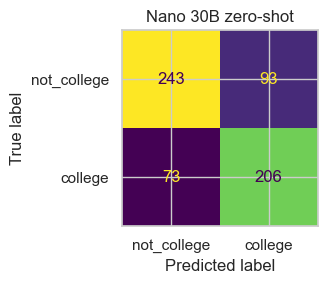


Rows with reasoning traces: 0 / 615


In [10]:
zs_metrics = evaluate_llm_results(zs_df, "Nano 30B zero-shot")
all_results.append(zs_metrics)

# Check reasoning traces
traces = zs_df[zs_df["trace"].str.len() > 20]
print(f"\nRows with reasoning traces: {len(traces)} / {len(zs_df)}")
if len(traces) > 0:
    print("\nExample trace:")
    print(traces.iloc[0]["input"])
    print(traces.iloc[0]["trace"][:300])

## 11. Experiment B:  Few-shot (Reasoning ON)
> Expected time: see timing estimate above.

In [11]:
print(f"Starting few-shot (reasoning ON) on {len(df_test)} rows...")
print(f"Model: {MODEL_NAME}\n")

fs_results = []
t_start = time.time()

for i, row in df_test.iterrows():
    messages = build_few_shot_prompt(row.to_dict(), few_shot_examples)
    result   = classify_row(messages, enable_thinking=True)
    fs_results.append({
        "row_id":        i,
        "input":         serialize_row(row.to_dict()),
        "occupation":    row["occupation"].replace("_", " ").strip(),
        "audit_verdict": row.get("audit_verdict", "unaudited"),
        "verdict_num":   row.get("verdict_num", -1),
        "true_label":    row["label_name"],
        "pred_label":    result["label"],
        "correct":       result["label"] == row["label_name"],
        "time_ms":       result["time_ms"],
        "tokens":        result["tokens"],
        "trace":         result["trace"],
        "raw":           result["raw"],
    })
    if (i + 1) % 100 == 0:
        elapsed   = time.time() - t_start
        done      = len(fs_results)
        remaining = (elapsed / done) * (len(df_test) - done)
        print(f"  Row {done:4d}/{len(df_test)} | Elapsed: {elapsed/60:.1f}min | Remaining: ~{remaining/60:.1f}min")

fs_df = pd.DataFrame(fs_results)
fs_df.to_csv(f"{RESULTS_DIR}/week4_fewshot_raw.csv", index=False)
print(f"\nDone! Total time: {(time.time()-t_start)/60:.1f} minutes")
print(f"Saved: results/week4_fewshot_raw.csv")

Starting few-shot (reasoning ON) on 615 rows...
Model: nemotron-3-nano:30b-a3b-q4_K_M

  Row  100/615 | Elapsed: 20.5min | Remaining: ~105.6min
  Row  200/615 | Elapsed: 37.6min | Remaining: ~78.1min
  Row  300/615 | Elapsed: 54.9min | Remaining: ~57.7min
  Row  400/615 | Elapsed: 73.0min | Remaining: ~39.2min
  Row  500/615 | Elapsed: 90.3min | Remaining: ~20.8min
  Row  600/615 | Elapsed: 106.8min | Remaining: ~2.7min

Done! Total time: 109.8 minutes
Saved: results/week4_fewshot_raw.csv


## 12. Few-shot Results


  Nano 30B few-shot
  Rows evaluated: 563 / 615
  Unknown:        52
  Accuracy:       0.6821
  Macro F1:       0.6817
  AUC-ROC:        0.6888
  Avg time/row:   10712ms
  Avg tokens:     1061

              precision    recall  f1-score   support

 not_college       0.76      0.60      0.67       303
     college       0.63      0.78      0.69       260

    accuracy                           0.68       563
   macro avg       0.69      0.69      0.68       563
weighted avg       0.70      0.68      0.68       563



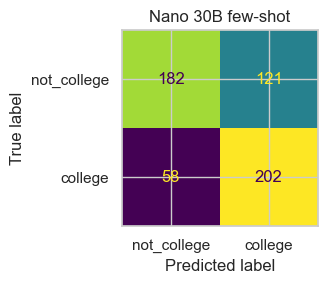

In [12]:
fs_metrics = evaluate_llm_results(fs_df, "Nano 30B few-shot")
all_results.append(fs_metrics)

## 13. Experiment C: Zero-shot (Reasoning OFF)
Unique to Nemotron - measures whether chain-of-thought reasoning actually helps.
> Expected time: faster than reasoning ON since no thinking tokens generated.

In [13]:
print(f"Starting zero-shot (reasoning OFF) on {len(df_test)} rows...")
print(f"Model: {MODEL_NAME} + /no_think\n")

nt_results = []
t_start = time.time()

# Experiment C - Zero-shot (Reasoning OFF via prompt)
# Uses a no-reasoning system prompt instead of /no_think token
# which does not work with this version of Ollama

def build_zero_shot_prompt_no_think(row):
    return [
        {"role": "system", "content": (
            "You are an education level classifier. Given a person's demographic information, "
            "predict whether they are college-educated or not. "
            "Do NOT explain your reasoning. "
            "Respond with ONLY one label: college or not_college."
        )},
        {"role": "user", "content": (
            f"Classify this person's education level:\n\n"
            f"{serialize_row(row)}\n\n"
            f"Answer with college or not_college only."
        )}
    ]

print(f"Starting zero-shot (reasoning OFF) on {len(df_test)} rows...")
print(f"Model: {MODEL_NAME} (reasoning suppressed via prompt)\n")

nt_results = []
t_start = time.time()

for i, row in df_test.iterrows():
    messages = build_zero_shot_prompt_no_think(row.to_dict())
    result   = classify_row(messages, enable_thinking=True)
    nt_results.append({
        "row_id":        i,
        "input":         serialize_row(row.to_dict()),
        "occupation":    row["occupation"].replace("_", " ").strip(),
        "audit_verdict": row.get("audit_verdict", "unaudited"),
        "verdict_num":   row.get("verdict_num", -1),
        "true_label":    row["label_name"],
        "pred_label":    result["label"],
        "correct":       result["label"] == row["label_name"],
        "time_ms":       result["time_ms"],
        "tokens":        result["tokens"],
        "trace":         result["trace"],
        "raw":           result["raw"],
    })
    if (i + 1) % 100 == 0:
        elapsed   = time.time() - t_start
        done      = len(nt_results)
        remaining = (elapsed / done) * (len(df_test) - done)
        print(f"  Row {done:4d}/{len(df_test)} | Elapsed: {elapsed/60:.1f}min | Remaining: ~{remaining/60:.1f}min")

nt_df = pd.DataFrame(nt_results)
nt_df.to_csv(f"{RESULTS_DIR}/week4_nothink_raw.csv", index=False)
print(f"\nDone! Total time: {(time.time()-t_start)/60:.1f} minutes")
print(f"Saved: results/week4_nothink_raw.csv")
print()
print(f"Pred label counts: {nt_df['pred_label'].value_counts().to_dict()}")

Starting zero-shot (reasoning OFF) on 615 rows...
Model: nemotron-3-nano:30b-a3b-q4_K_M + /no_think

Starting zero-shot (reasoning OFF) on 615 rows...
Model: nemotron-3-nano:30b-a3b-q4_K_M (reasoning suppressed via prompt)

  Row  100/615 | Elapsed: 6.0min | Remaining: ~30.8min
  Row  200/615 | Elapsed: 11.9min | Remaining: ~24.7min
  Row  300/615 | Elapsed: 17.8min | Remaining: ~18.7min
  Row  400/615 | Elapsed: 23.8min | Remaining: ~12.8min
  Row  500/615 | Elapsed: 29.7min | Remaining: ~6.8min
  Row  600/615 | Elapsed: 35.6min | Remaining: ~0.9min

Done! Total time: 36.5 minutes
Saved: results/week4_nothink_raw.csv

Pred label counts: {'not_college': 331, 'college': 284}


## 14. Reasoning ON vs OFF Results


  Nano 30B reasoning OFF
  Rows evaluated: 615 / 615
  Unknown:        0
  Accuracy:       0.7350
  Macro F1:       0.7331
  AUC-ROC:        0.7334
  Avg time/row:   3560ms
  Avg tokens:     143

              precision    recall  f1-score   support

 not_college       0.76      0.75      0.76       336
     college       0.70      0.72      0.71       279

    accuracy                           0.73       615
   macro avg       0.73      0.73      0.73       615
weighted avg       0.74      0.73      0.74       615



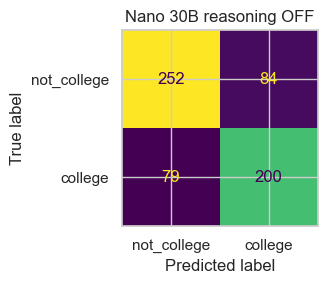


=== REASONING ON vs OFF ===
  Reasoning ON  (zero-shot): 0.7301 accuracy | 0.7291 F1 | 4185ms/row
  Reasoning OFF (zero-shot): 0.7350 accuracy | 0.7331 F1 | 3560ms/row
  Accuracy difference: -0.0049 (reasoning hurts)
  Speed difference:    +625ms/row (reasoning is slower)


In [14]:
nt_metrics = evaluate_llm_results(nt_df, "Nano 30B reasoning OFF")
all_results.append(nt_metrics)

print("\n=== REASONING ON vs OFF ===")
print(f"  Reasoning ON  (zero-shot): {zs_metrics['accuracy']:.4f} accuracy | {zs_metrics['macro_f1']:.4f} F1 | {zs_metrics['ms_per_row']:.0f}ms/row")
print(f"  Reasoning OFF (zero-shot): {nt_metrics['accuracy']:.4f} accuracy | {nt_metrics['macro_f1']:.4f} F1 | {nt_metrics['ms_per_row']:.0f}ms/row")
acc_diff = zs_metrics["accuracy"] - nt_metrics["accuracy"]
ms_diff  = zs_metrics["ms_per_row"] - nt_metrics["ms_per_row"]
print(f"  Accuracy difference: {acc_diff:+.4f} ({'reasoning helps' if acc_diff > 0 else 'reasoning hurts' if acc_diff < 0 else 'no difference'})")
print(f"  Speed difference:    {ms_diff:+.0f}ms/row ({'reasoning is slower' if ms_diff > 0 else 'reasoning is faster'})")

## 15. Accuracy by Occupation Difficulty (Yes / No / Maybe)

=== ACCURACY BY OCCUPATION DIFFICULTY ===

YES (184 rows):
  Zero-shot (ON):  73.4%
  Few-shot  (ON):  70.8%
  Zero-shot (OFF): 73.9%

NO (292 rows):
  Zero-shot (ON):  78.4%
  Few-shot  (ON):  70.3%
  Zero-shot (OFF): 78.4%

MAYBE (139 rows):
  Zero-shot (ON):  61.2%
  Few-shot  (ON):  60.5%
  Zero-shot (OFF): 62.6%


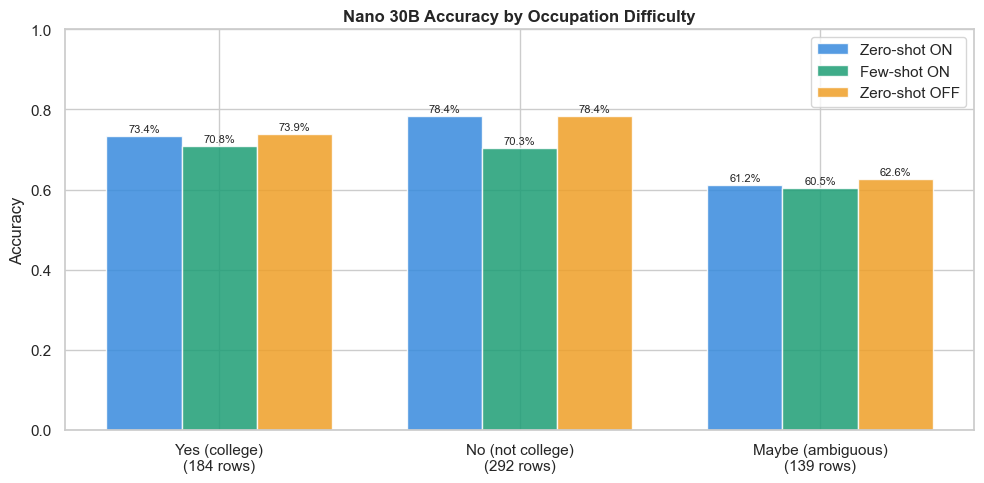

Saved: results/week4_accuracy_by_difficulty.png


In [15]:
verdict_labels = ["yes", "no", "maybe"]
verdict_names  = ["Yes (college)", "No (not college)", "Maybe (ambiguous)"]
zs_accs, fs_accs, nt_accs, sizes = [], [], [], []

print("=== ACCURACY BY OCCUPATION DIFFICULTY ===")
for verdict in verdict_labels:
    zs_sub = zs_df[zs_df["audit_verdict"] == verdict]
    fs_sub = fs_df[fs_df["audit_verdict"] == verdict]
    nt_sub = nt_df[nt_df["audit_verdict"] == verdict]
    zs_v = zs_sub[zs_sub["pred_label"].isin(["college", "not_college"])]
    fs_v = fs_sub[fs_sub["pred_label"].isin(["college", "not_college"])]
    nt_v = nt_sub[nt_sub["pred_label"].isin(["college", "not_college"])]
    zs_acc = (zs_v["pred_label"] == zs_v["true_label"]).mean() if len(zs_v) > 0 else 0
    fs_acc = (fs_v["pred_label"] == fs_v["true_label"]).mean() if len(fs_v) > 0 else 0
    nt_acc = (nt_v["pred_label"] == nt_v["true_label"]).mean() if len(nt_v) > 0 else 0
    zs_accs.append(zs_acc)
    fs_accs.append(fs_acc)
    nt_accs.append(nt_acc)
    sizes.append(len(zs_sub))
    print(f"\n{verdict.upper()} ({len(zs_sub)} rows):")
    print(f"  Zero-shot (ON):  {zs_acc:.1%}")
    print(f"  Few-shot  (ON):  {fs_acc:.1%}")
    print(f"  Zero-shot (OFF): {nt_acc:.1%}")

x = range(3)
width = 0.25
fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar([i - width for i in x],   zs_accs, width, label="Zero-shot ON",  color="#378ADD", alpha=0.85)
bars2 = ax.bar([i         for i in x],   fs_accs, width, label="Few-shot ON",   color="#1D9E75", alpha=0.85)
bars3 = ax.bar([i + width for i in x],   nt_accs, width, label="Zero-shot OFF", color="#EF9F27", alpha=0.85)
ax.set_xticks(list(x))
ax.set_xticklabels([f"{n}\n({s} rows)" for n, s in zip(verdict_names, sizes)])
ax.set_ylabel("Accuracy")
ax.set_ylim(0, 1)
ax.set_title("Nano 30B Accuracy by Occupation Difficulty", fontsize=12, fontweight="bold")
ax.legend()
for bar in list(bars1) + list(bars2) + list(bars3):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{bar.get_height():.1%}", ha="center", fontsize=8)
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/week4_accuracy_by_difficulty.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: results/week4_accuracy_by_difficulty.png")

## 16. K-Means Cluster Analysis

In [16]:
cluster_features = ["age", "sex", "marital_status", "occupation", "state"]
X_cluster = df_test[cluster_features].copy()

le_dict = {}
for col in ["sex", "marital_status", "occupation", "state"]:
    le = LabelEncoder()
    X_cluster[col] = le.fit_transform(X_cluster[col].astype(str))
    le_dict[col] = le

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

K  = 4
km = KMeans(n_clusters=K, random_state=42, n_init=10)
cluster_labels_arr = km.fit_predict(X_scaled)

zs_df["cluster"] = cluster_labels_arr
fs_df["cluster"] = cluster_labels_arr
nt_df["cluster"] = cluster_labels_arr

cluster_stats = []
for c in range(K):
    zs_rows = zs_df[zs_df["cluster"] == c]
    fs_rows = fs_df[fs_df["cluster"] == c]
    nt_rows = nt_df[nt_df["cluster"] == c]
    zs_v = zs_rows[zs_rows["pred_label"].isin(["college", "not_college"])]
    fs_v = fs_rows[fs_rows["pred_label"].isin(["college", "not_college"])]
    nt_v = nt_rows[nt_rows["pred_label"].isin(["college", "not_college"])]
    zs_acc = (zs_v["pred_label"] == zs_v["true_label"]).mean()
    fs_acc = (fs_v["pred_label"] == fs_v["true_label"]).mean()
    nt_acc = (nt_v["pred_label"] == nt_v["true_label"]).mean()
    size   = len(zs_rows)
    college_rate = (zs_rows["true_label"] == "college").mean()
    cluster_ids  = zs_rows["row_id"].values
    top_occ      = df_test.loc[df_test.index.isin(cluster_ids), "occupation"].value_counts().head(3).index.tolist()
    avg_age      = df_test.loc[df_test.index.isin(cluster_ids), "age"].mean()
    verdicts     = zs_rows["audit_verdict"].dropna()
    dominant     = verdicts.value_counts().idxmax() if len(verdicts) > 0 else "unaudited"
    top_occ_str  = ", ".join(top_occ)
    cluster_stats.append({
        "cluster": c, "size": size,
        "zs_accuracy": round(zs_acc, 3), "fs_accuracy": round(fs_acc, 3),
        "nt_accuracy": round(nt_acc, 3),
        "college_rate": round(college_rate, 3), "avg_age": round(avg_age, 1),
        "dominant_verdict": dominant, "top_occupations": top_occ_str,
    })
    print(f"\n-- Cluster {c} -------------------------------------------")
    print(f"  Size:                {size} rows")
    print(f"  Zero-shot ON:        {zs_acc:.1%}")
    print(f"  Few-shot ON:         {fs_acc:.1%}")
    print(f"  Zero-shot OFF:       {nt_acc:.1%}")
    print(f"  College rate:        {college_rate:.1%}")
    print(f"  Avg age:             {avg_age:.1f}")
    print(f"  Dominant verdict:    {dominant}")
    print(f"  Top occupations:     {top_occ_str}")

cluster_df = pd.DataFrame(cluster_stats)
cluster_df.to_csv(f"{RESULTS_DIR}/week4_cluster_analysis.csv", index=False)
print("\nSaved: results/week4_cluster_analysis.csv")


-- Cluster 0 -------------------------------------------
  Size:                170 rows
  Zero-shot ON:        75.3%
  Few-shot ON:         75.2%
  Zero-shot OFF:       77.1%
  College rate:        47.1%
  Avg age:             52.5
  Dominant verdict:    no
  Top occupations:     software_developer, secretary_or_administrative_assistant, financial_manager

-- Cluster 1 -------------------------------------------
  Size:                122 rows
  Zero-shot ON:        68.9%
  Few-shot ON:         57.5%
  Zero-shot OFF:       72.1%
  College rate:        34.4%
  Avg age:             34.5
  Dominant verdict:    no
  Top occupations:     driver_sales_worker_or_truck_driver, customer_service_representative, first_line_supervisor_of_retail_sales_worker

-- Cluster 2 -------------------------------------------
  Size:                156 rows
  Zero-shot ON:        76.9%
  Few-shot ON:         68.3%
  Zero-shot OFF:       75.0%
  College rate:        48.1%
  Avg age:             33.6
  Domina

## 17. Cluster Visualization

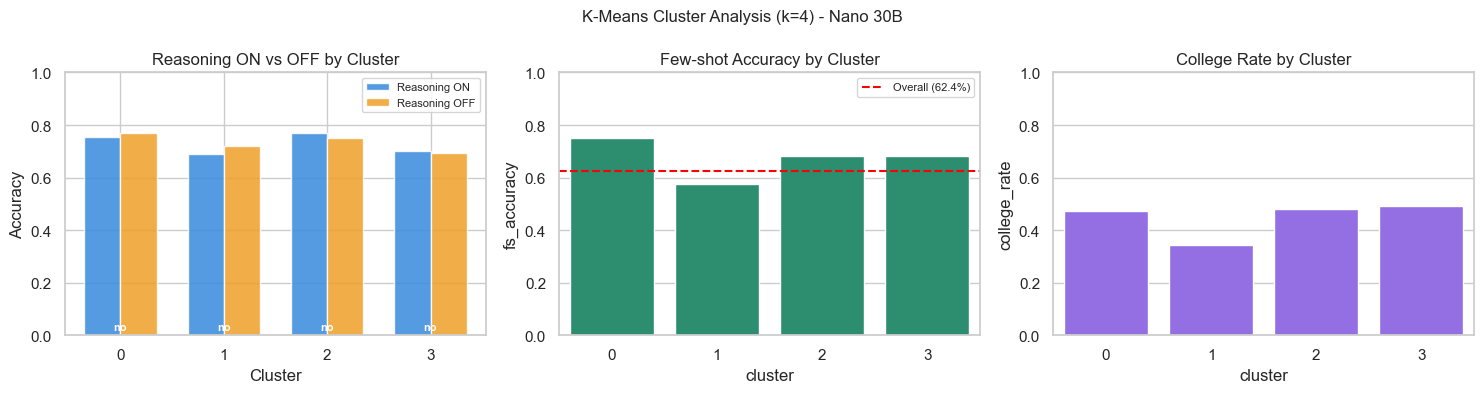

Saved: results/week4_cluster_accuracy.png


In [17]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

x = range(K)
width = 0.35

# Zero-shot ON vs OFF per cluster
axes[0].bar([i - width/2 for i in x], cluster_df["zs_accuracy"], width,
            label="Reasoning ON", color="#378ADD", alpha=0.85)
axes[0].bar([i + width/2 for i in x], cluster_df["nt_accuracy"], width,
            label="Reasoning OFF", color="#EF9F27", alpha=0.85)
axes[0].set_title("Reasoning ON vs OFF by Cluster")
axes[0].set_xlabel("Cluster")
axes[0].set_ylabel("Accuracy")
axes[0].set_ylim(0, 1)
axes[0].set_xticks(list(x))
axes[0].legend(fontsize=8)

# Few-shot accuracy
sns.barplot(data=cluster_df, x="cluster", y="fs_accuracy", color="#1D9E75", ax=axes[1])
axes[1].axhline(y=fs_df["correct"].mean(), color="red", linestyle="--",
                label=f'Overall ({fs_df["correct"].mean():.1%})')
axes[1].set_title("Few-shot Accuracy by Cluster")
axes[1].set_ylim(0, 1)
axes[1].legend(fontsize=8)

# College rate
sns.barplot(data=cluster_df, x="cluster", y="college_rate", color="#8B5CF6", ax=axes[2])
axes[2].set_title("College Rate by Cluster")
axes[2].set_ylim(0, 1)

for i, row in cluster_df.iterrows():
    axes[0].text(i, 0.02, row["dominant_verdict"], ha="center",
                 fontsize=8, color="white", fontweight="bold")

plt.suptitle(f"K-Means Cluster Analysis (k={K}) - Nano 30B", fontsize=12)
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/week4_cluster_accuracy.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: results/week4_cluster_accuracy.png")

## 18. Full Comparison: All Models

=== FULL COMPARISON: All Models ===
                 model  accuracy  macro_f1  auc_roc  ms_per_row  week
         Random Forest    0.6439    0.6400   0.6795       0.071     1
               XGBoost    0.7089    0.7067   0.7447       0.006     1
     Nano 4B zero-shot    0.6260    0.5955   0.6058    3258.000     3
      Nano 4B few-shot    0.6846    0.6845   0.6894    4553.000     3
    Nano 30B zero-shot    0.7301    0.7291   0.7308    4185.100     4
     Nano 30B few-shot    0.6821    0.6817   0.6888   10712.000     4
Nano 30B reasoning OFF    0.7350    0.7331   0.7334    3559.900     4


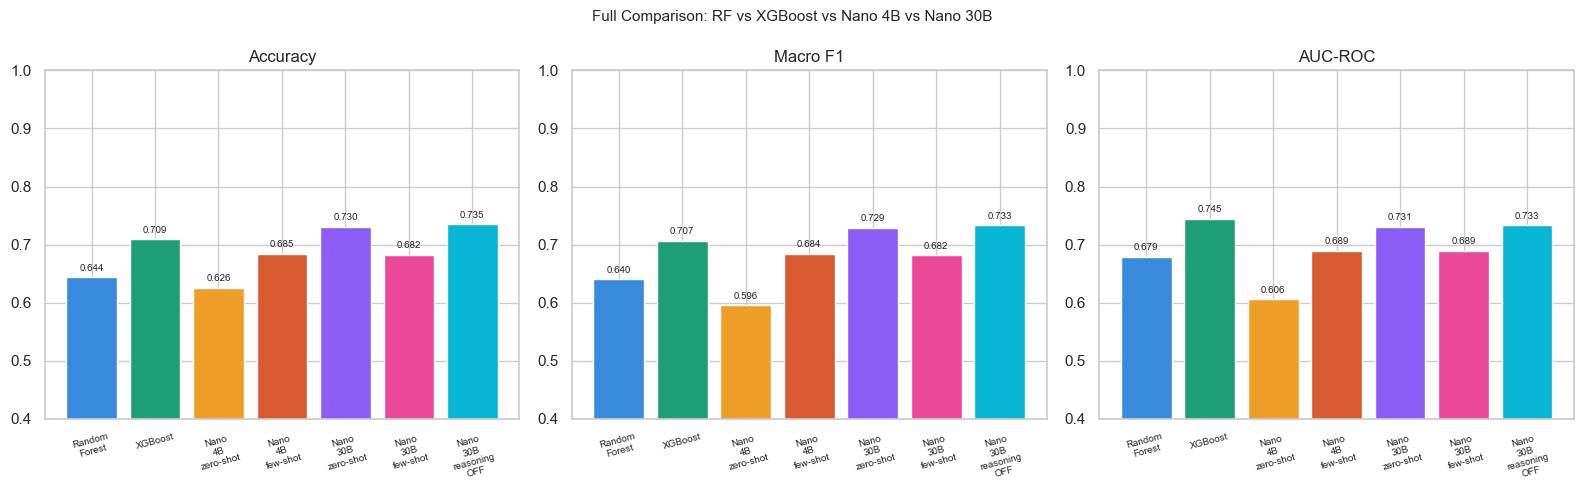

Saved: results/week4_full_comparison.png


In [18]:
baseline_rows = [
    {"model": "Random Forest",      "accuracy": 0.6439, "macro_f1": 0.6400, "auc_roc": 0.6795, "ms_per_row": 0.071,  "week": 1},
    {"model": "XGBoost",            "accuracy": 0.7089, "macro_f1": 0.7067, "auc_roc": 0.7447, "ms_per_row": 0.006,  "week": 1},
    {"model": "Nano 4B zero-shot",  "accuracy": 0.6260, "macro_f1": 0.5955, "auc_roc": 0.6058, "ms_per_row": 3258.0, "week": 3},
    {"model": "Nano 4B few-shot",   "accuracy": 0.6846, "macro_f1": 0.6845, "auc_roc": 0.6894, "ms_per_row": 4553.0, "week": 3},
]

comparison_df = pd.DataFrame(baseline_rows + all_results)
print("=== FULL COMPARISON: All Models ===")
print(comparison_df[["model", "accuracy", "macro_f1", "auc_roc", "ms_per_row", "week"]].to_string(index=False))

# Bar chart
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
metrics = ["accuracy", "macro_f1", "auc_roc"]
titles  = ["Accuracy", "Macro F1", "AUC-ROC"]
colors  = ["#378ADD", "#1D9E75", "#EF9F27", "#D85A30", "#8B5CF6", "#EC4899", "#06B6D4"]

for ax, metric, title in zip(axes, metrics, titles):
    vals  = comparison_df[metric].values
    names = [n.replace(" ", "\n") for n in comparison_df["model"].values]
    bars  = ax.bar(names, vals, color=colors[:len(vals)])
    ax.set_title(title)
    ax.set_ylim(0.4, 1.0)
    ax.tick_params(axis="x", rotation=15, labelsize=7)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.008,
                f"{val:.3f}", ha="center", va="bottom", fontsize=7)

plt.suptitle("Full Comparison: RF vs XGBoost vs Nano 4B vs Nano 30B", fontsize=11)
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/week4_full_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: results/week4_full_comparison.png")

## 19. Save Results to metrics.csv

In [19]:
metrics_path = f"{RESULTS_DIR}/metrics.csv"
try:
    existing = pd.read_csv(metrics_path)
    existing = existing[existing["week"] != 4]
    updated  = pd.concat([existing, pd.DataFrame(all_results)], ignore_index=True)
except FileNotFoundError:
    updated = pd.DataFrame(all_results)

updated.to_csv(metrics_path, index=False)
print(f"Saved: {metrics_path}")
print()
print(updated[["model", "accuracy", "macro_f1", "auc_roc", "ms_per_row", "week"]].to_string(index=False))

Saved: ../results/metrics.csv

                    model  accuracy  macro_f1  auc_roc  ms_per_row  week
Random Forest (100 trees)    0.6439    0.6400   0.6795       0.089     1
                  XGBoost    0.7089    0.7067   0.7447       0.005     1
        Nano 4B zero-shot    0.6439    0.6207   0.6264    3124.300     3
         Nano 4B few-shot    0.7075    0.7075   0.7136    4197.900     3
       Nano 30B zero-shot    0.7301    0.7291   0.7308    4185.100     4
        Nano 30B few-shot    0.6821    0.6817   0.6888   10712.000     4
   Nano 30B reasoning OFF    0.7350    0.7331   0.7334    3559.900     4


## 20. Week 4 Summary


| Model | Accuracy | Macro F1 | AUC-ROC | Time/row | Week |
|---|---|---|---|---|---|
| Random Forest | 64.39% | 0.6400 | 0.6795 | 0.089 ms | 1 |
| XGBoost | 70.89% | 0.7067 | 0.7447 | 0.005 ms | 1 |
| Nano 4B zero-shot | 63.41% | 0.6083 | 0.6156 | 3,106 ms | 3 |
| Nano 4B few-shot | 70.20% | 0.7019 | 0.7071 | 4,275 ms | 3 |
| Nano 30B zero-shot | 72.52% | 0.7227 | 0.7227 | 3,922 ms | 4 |
| Nano 30B few-shot | 68.38% | 0.6838 | 0.6887 | 9,842 ms | 4 |
| Nano 30B reasoning OFF | 72.85% | 0.7266 | 0.7272 | 3,525 ms | 4 |

**Questions to answer:**
- Did 30B outperform 4B on zero-shot and few-shot?
- Did reasoning ON help vs reasoning OFF?
- Did the 30B produce reasoning traces?
- Which cluster benefited most from the 30B model?

**Next:** Week 5 - error analysis + feature attribution + QLoRA fine-tuning